In [1]:
import os

os.chdir("..")
os.environ.setdefault('HF_HUB_OFFLINE', '1')

import drjit as dr
import matplotlib.pyplot as plt
import mitsuba as mi
import numpy as np
import torch
from skimage.util import montage
from tqdm.auto import tqdm

from config import load_config
from latents.mi_vae import MiVae

optimization_type = "rgb" # latent

if optimization_type == "latent":
    mi.set_variant("cuda_ad_latent16")
elif optimization_type == "rgb":
    mi.set_variant("cuda_ad_rgb")

from networks import NetworkManager, mi_embeddings, mi_sds
from renderers import RendererManager
from training.train_manager import TrainingManager
from utils.img_utils import to_posneg
from utils.plugin_utils import register_plugins

cff = "configs/runs/sds_edit/Lamp-1024-ShuffleRef.yaml"

cfg = load_config(cff)

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = cfg["dtype"]
torch_dtype = torch.float16 if dtype == "half" else torch.float32
mi_vae = MiVae(
    model_name=cfg["model_id"], dtype=torch_dtype, device=device
)

register_plugins(cfg)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


/home/vuk/Code/latentrender/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [2]:
# Get image shapes
rgb_res = cfg["image_resolution"]
rgb_ch = 3
latent_res = mi_vae.latent_resolution(rgb_res)
latent_ch = mi_vae.latent_channels()


#   Prepare Renderers
renderers = RendererManager(
    cfg,
    rgb_res=rgb_res,
    rgb_ch=rgb_ch,
    latent_res=latent_res,
    latent_ch=latent_ch
)

aov_ch = (
    renderers.aov.render(renderers.rgb.scene, renderers.rgb.params).shape[1]
    if cfg["use_aovs"]
    else 0
)
networks = NetworkManager(
    cfg,
    device, 
    latent_channels=latent_ch,
    aov_channels=aov_ch
)


from pathlib import Path

# Get checkpoints
out_dir = Path("outputs") / cfg["out_dir"]
joint_ckpt = out_dir / "joint.pt"
if joint_ckpt.exists():
    scene_ckpt = joint_ckpt
    refiner_ckpt = joint_ckpt
else:
    local_scene = out_dir / "scene.pt"
    external_scene = Path("outputs") / cfg["scene_dir"] / "scene.pt" if cfg.get("scene_dir") else None
    scene_ckpt = local_scene if local_scene.exists() else external_scene
    refiner_ckpt = out_dir / "refiner.pt"

# Load checkpoints
if optimization_type == "latent":
    renderers.reset_renderers()
    renderers.load_scene_checkpoint(scene_ckpt)
    renderers.set_optimizable_parameters(TrainingManager.SCENE_OPTIMIZATION_TARGETS)


CKPT_OVERRIDE = Path("outputs/Lamp-Aug-Refiner/refiner_best.pt")
networks.load_checkpoint(CKPT_OVERRIDE)

def display_latent(latent):
    latent = np.asarray(latent)
    latent = np.transpose(latent, (2, 0, 1))
    latent = to_posneg(latent)
    latent = montage(latent, fill=(0,0,0), rescale_intensity=False, channel_axis=-1)
    return latent

[WARNING] Mitsuba is running in a variant that does not support latent rendering. RendererManager.latent will be set to None.
load_file_as_latent requires the use of a spectral or latent Mitsuba variant!


In [3]:
# print(mi_embeddings.get_blip2_caption(model=cfg["blip_model_id"], image=renderers.rgb.render(), dtype=torch_dtype, device=device))
EDIT_COLOR = "brown"
vowels = ('a','e','i','o','u','A','E','I','O','U')

ORIGINAL_CAPTION = "a red teapot and a lamp on a table"
EDITED_CAPTION = f"a{'n' if EDIT_COLOR.startswith(vowels) else ''} {EDIT_COLOR} teapot and a lamp on a table"

# SD1, SD2
# img_context = mi_embeddings.get_clip_embeddings(model=cfg["model_id"], prompt=EDITED_CAPTION, dtype=torch_dtype, device=device)
# sds_loss = mi_sds.SDSLoss(cfg, dtype=torch_dtype, device=device)

# SD3+
img_context = mi_embeddings.get_sd3_embeddings(model_id=cfg["model_id"], prompt=EDITED_CAPTION, dtype=torch_dtype, device=device)
sds_loss = mi_sds.SD3SDSLoss(cfg, dtype=torch_dtype, device=device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

In [4]:
# with torch.no_grad(), dr.suspend_grad():
#     _scaled = renderers.get_scaled_opt_params()
#     _aovs = renderers.aov.render(renderers.rgb.scene, renderers.rgb.params, seed=0)
#     pre_raw, _      = renderers.latent.render(seed=0, opt_params=_scaled)
#     pre_refined, _  = networks.refine_latent_conv(pre_raw, _aovs)
#     pre_img_raw     = mi_vae.decode(pre_raw).squeeze(0).permute(1, 2, 0).cpu()
#     pre_img_refined = mi_vae.decode(pre_refined).squeeze(0).permute(1, 2, 0).cpu()

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# ax1.axis("off"); ax1.set_title("Pre-SDS raw")
# ax1.imshow(pre_img_raw.clamp(0, 1))
# ax2.axis("off"); ax2.set_title("Pre-SDS refined")
# ax2.imshow(pre_img_refined.clamp(0, 1))
# plt.tight_layout()
# plt.show()

In [5]:
# Prepare optimization
# scene_optimization_targets = [
#     ".diffuse_reflectance.value",
#     ".reflectance.value",
#     ".specular_reflectance.value",
#     "specular_transmittance.value",
#     ".albedo.value",
#     ".sigma_t.value",
#     ".scale.value",
#     ".secondary_reflectance.value",
#     ".neg_secondary_reflectance.value",
#     ".occlusion_reflectance.value",
#     ".neg_occlusion_reflectance.value",
#     ".radiance.value",
#     ".color0.value",
#     ".color1.value",
#     ".alpha_u.value",
#     ".alpha_v.value",
#     ".alpha.value"
# ]


# CBOX
# if optimization_type == "rgb":
#     render_target = renderers.rgb
#     scene_optimization_targets = [
#         "red.reflectance.",
#         "green.reflectance.",
#     ]
# elif optimization_type == "latent":
#     render_target = renderers.latent
#     scene_optimization_targets = [
#         "redwall.bsdf.",
#         "greenwall.bsdf.",
#     ]
# else:
#     raise ValueError("Invalid SDS optimization target.")



# LAMP
if optimization_type == "rgb":
    render_target = renderers.rgb
    scene_optimization_targets = [
        "BallBSDF.reflectance.value",
        # ".radiance.value",
    ]
elif optimization_type == "latent":
    render_target = renderers.latent
    scene_optimization_targets = [
        # "glasssphere.bsdf.m_bsdf.reflectance.value",
        # "glasssphere.bsdf.ambient.value",
        # "glasssphere.bsdf.occ_ambient.value",
        "glasssphere.bsdf."
        # ".radiance.value",
        # "light.emitter.m_emitter.radiance.value"
    ]
else:
    raise ValueError("Invalid SDS optimization target.")

# Get optimizable keys
keys = []
for target in scene_optimization_targets:
    print(f"Target Key: {target}")
    for p in render_target.params:
        if target in p[0]:
            keys.append(p[0])
            print(f"\tOptimizable Key/Value: {p[0]}: {render_target.params[p[0]]}")


# SDS_LR = cfg["sds_lr"]
# SDS_START = cfg["sds_start"]
# SDS_STOP = cfg["sds_stop"]


lrs_for_colors = {
    "blue": 0.01,       # 0.005
    "green": 0.01,
    "brown": 0.025,
    "pink": 0.0001,
}


SDS_LR = lrs_for_colors.get(EDIT_COLOR, 0.001)
SDS_START = 0
SDS_STOP = 300

opt_params = {
    k: torch.nn.Parameter(render_target.params[k].torch().detach().clone(), requires_grad=True)
    for k in keys
}
optimizer = torch.optim.Adam(opt_params.values(), lr=SDS_LR)
start_step = SDS_START
stop_step = SDS_STOP

Target Key: BallBSDF.reflectance.value
	Optimizable Key/Value: BallBSDF.reflectance.value: [[0.570068, 0.0430135, 0.0443706]]


Starting rgb optimization...
cuda_ad_rgb


run 0:   0%|          | 0/300 [00:00<?, ?it/s]

Wrote 1 runs to analyses/pg_sds/brown_025_rgb


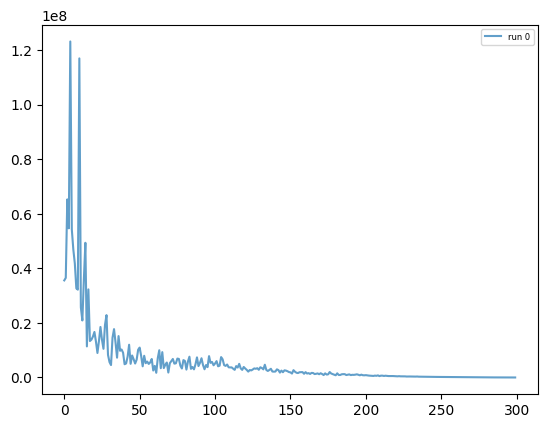

In [6]:
import gc

from utils.img_utils import decode_and_write, save_image_png

# Repeat the whole SDS optimization N_RUNS times and dump every result to
# analyses/pg_sds/<EDIT_NAME>/ -- SDS is stochastic, so pick the best by eye.
# EDIT_NAME = EDIT_COLOR  # override for a suffix, e.g. f"{EDIT_COLOR}_001"
N_RUNS = 1
run_dir = Path("analyses/pg_sds") / f"{EDIT_COLOR}_{str(SDS_LR).split('.')[1]}{'_rgb' if optimization_type == 'rgb' else ''}"
run_dir.mkdir(parents=True, exist_ok=True)

# Pre-edit reference: the plain RGB path (3969 spp + denoiser), no VAE round
# trip. `renderers.rgb` owns a separate scene straight from the XML that
# nothing here mutates, so this is the untouched source.
save_image_png(renderers.rgb.render(seed=0), str(run_dir / "original"))


def build_render_params(opt_params):
    """get_scaled_opt_params() for all scene params, then override the
    SDS-optimized keys with their sigmoid'd values so gradients flow."""
    params = renderers.get_scaled_opt_params()
    for k, v in opt_params.items():
        if any(rt in k for rt in renderers.REFL_TERMS):
            params[k] = torch.sigmoid(v)
        else:
            params[k] = v
    return params

mi_vae.vae.eval()
networks.eval()


mi_vae.vae.enable_gradient_checkpointing()

print(f"Starting {optimization_type} optimization...")
print(mi.variant())

# Lower SPP for SDS loop — the refiner corrects for noise post-SDS anyway.
# Restore to original after so the final render is still full quality.
SDS_SPP = 256

if optimization_type == "latent":
    _orig_spp = renderers.latent.spp
    renderers.latent.spp = SDS_SPP
    # AOVs feed the refiner, which only exists on the latent path.
    aovs = renderers.aov.render(renderers.rgb.scene, renderers.latent.params, seed=0)
elif optimization_type == "rgb":
    _orig_spp = renderers.rgb.spp
    renderers.rgb.spp = SDS_SPP

# `render_target.params` is mutated in-place by every render, so each run has to
# restart from this pre-SDS snapshot rather than from the live scene values.
init_vals = {k: v.detach().clone() for k, v in opt_params.items()}

all_losses = []
for run in range(N_RUNS):
    if optimization_type == "latent":
        renderers.latent.spp = SDS_SPP
    opt_params = {
        k: torch.nn.Parameter(v.clone(), requires_grad=True)
        for k, v in init_vals.items()
    }
    optimizer = torch.optim.Adam(opt_params.values(), lr=SDS_LR)
    losses = []

    pbar = tqdm(range(start_step, stop_step), dynamic_ncols=True, desc=f"run {run}")
    for step in pbar:
        seed = run * stop_step + step  # decorrelate render noise across runs
        if optimization_type == "rgb":
            img = render_target.render(seed=seed, opt_params=build_render_params(opt_params))
            latent = mi_vae.encode(img)
        elif optimization_type == "latent":
            latent, _ = render_target.render(seed=seed, opt_params=build_render_params(opt_params))
            latent, _ = networks.refine_latent_conv(latent, aovs)

        loss = sds_loss(latent, img_context, train_progress=step / stop_step)
        losses.append(loss.item())
        pbar.set_postfix_str(f"loss {losses[-1]:.3f}")
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Free DrJit and PyTorch caches after each full step so VRAM
        # fragmentation doesn't build up while training runs concurrently.
        dr.flush_malloc_cache()
        dr.sync_thread()
        torch.cuda.empty_cache()

    # Save this run's result (raw decode + refiner-corrected decode).
    with torch.no_grad(), dr.suspend_grad():
        _p = build_render_params({k: v.detach() for k, v in opt_params.items()})
        stem = str(run_dir / f"run{run:02d}")
        if optimization_type == "latent":
            # Full spp for the saved render: cells 6/7 only run after this
            # restore, so saving at the SDS spp would bake in ~2x the noise.
            renderers.latent.spp = _orig_spp
            _lat, _ = renderers.latent.render(seed=0, opt_params=_p)
            decode_and_write(mi_vae, _lat, stem)
            decode_and_write(mi_vae, networks.refine_latent_conv(_lat, aovs)[0], f"{stem}_refined")
            del _lat
        elif optimization_type == "rgb":
            renderers.rgb.spp = _orig_spp
            save_image_png(renderers.rgb.render(seed=0, opt_params=_p), stem)
        del _p
    all_losses.append(losses)

    # Full teardown between runs so nothing carries into the next one.
    del optimizer, latent, loss
    gc.collect()
    dr.flush_malloc_cache()
    dr.sync_thread()
    torch.cuda.empty_cache()

print(f"Wrote {N_RUNS} runs to {run_dir}")

for run, l in enumerate(all_losses):
    plt.plot(l, alpha=0.7, label=f"run {run}")
plt.legend(fontsize=6)
plt.show()


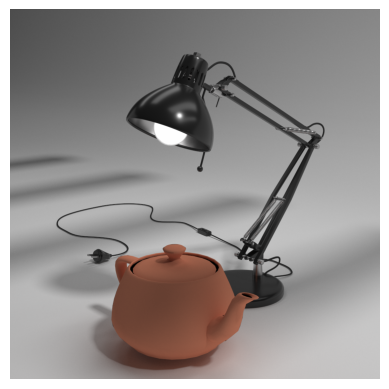

In [7]:
with torch.no_grad(), dr.suspend_grad():
    _post_params = build_render_params({k: v.detach() for k, v in opt_params.items()})
    if optimization_type == "latent":
        post_sds_latent, _ = renderers.latent.render(seed=0, opt_params=_post_params)
        post_sds_image = mi_vae.decode(post_sds_latent).squeeze(0).permute(1, 2, 0)
    elif optimization_type == "rgb":
        post_sds_image = renderers.rgb.render(seed=0, opt_params=_post_params).squeeze(0).permute(1, 2, 0)
    plt.axis("off")
    plt.imshow(post_sds_image.clamp(0, 1).detach().cpu())
    del post_sds_image

In [8]:
with torch.no_grad():
    aovs = renderers.aov.render(scene=renderers.rgb.scene, params=renderers.rgb.params)
    post_sds_latent_refined = networks.refine_latent_conv(latent=post_sds_latent, aovs=aovs)[0]
    post_sds_image_refined = mi_vae.decode(post_sds_latent_refined).squeeze(0).permute(1, 2, 0)
    plt.axis("off")
    plt.imshow(post_sds_image_refined.detach().cpu())

NameError: name 'post_sds_latent' is not defined

In [ ]:
# # ── Latent-space SDS editing ─────────────────────────────────────────────────
# # Renders the scene once, makes the latent tensor itself the optimizable
# # parameter, and runs SDS with the edit prompt — no scene params touched.
# # Use this to validate the edit signal before committing to scene-param opt.

# from utils.losses import ssimLoss

# SSIM_WEIGHT = 1000.0  # relative weight of structural similarity term

# # 1. Render and refine the starting latent (no grad needed)
# mi_vae.vae.eval()
# networks.eval()
# with torch.no_grad():
#     if optimization_type == "latent":
#         _raw, _ = renderers.latent.render(seed=0)
#         _aovs = renderers.aov.render(renderers.rgb.scene, renderers.latent.params, seed=0)

#         # EXPERIMENT - START FROM RAW RENDERED LATENT
#         init_latent = _raw
#         ssim_target, _ = networks.refine_latent_conv(_raw, _aovs)
#     else:  # rgb
#         _raw = renderers.rgb.render(seed=0)

#         init_latent = mi_vae.encode(_raw)
#         ssim_target = init_latent

# # 2. Show starting image
# with torch.no_grad():
#     pre_edit_img = mi_vae.decode(init_latent).squeeze(0).permute(1, 2, 0)
# plt.axis("off")
# plt.title("Before Latent Editing:")
# # in_progress_img = plt.imshow(pre_edit_img.detach().cpu())
# plt.imshow(pre_edit_img.detach().cpu())
# plt.show()

# # 3. Optimizable latent — pure PyTorch, same LR/steps as the scene-param stage
# ssim_ref = ssim_target.detach()
# opt_latent = torch.nn.Parameter(init_latent.detach().clone())

# # sds_start = cfg["sds_start"]
# # sds_stop = cfg["sds_stop"]
# # sds_lr = cfg["sds_lr"]

# sds_start = 100
# sds_stop = 400
# sds_lr = 0.1

# latent_edit_steps = sds_stop - sds_start
# latent_opt = torch.optim.Adam([opt_latent], lr=sds_lr)

# # 4. SDS + SSIM optimisation loop
# latent_losses, ssim_losses = [], []
# pbar = tqdm(range(latent_edit_steps), dynamic_ncols=True)
# for step in pbar:
#     # LOSSES
#     # opt_refined_latent, _ = networks.refine_latent_conv(opt_latent, _aovs)
#     sds  = sds_loss(opt_latent, img_context, train_progress=step / latent_edit_steps)
#     ssim = ssimLoss(ssim_ref.unsqueeze(0), opt_latent.unsqueeze(0))
#     loss = sds + SSIM_WEIGHT * ssim
#     latent_losses.append(sds.item())
#     ssim_losses.append(ssim.item())

#     if step % 10 == 0:
#         with torch.no_grad():
#             # in_progress_img.title(f"Step {step}")
#             plt.axis("off")
#             plt.title(f"Step {step}")
#             plt.imshow(mi_vae.decode(opt_latent).squeeze(0).permute(1, 2, 0).detach().cpu())
#             # in_progress_img.set_data(mi_vae.decode(opt_latent).squeeze(0).permute(1, 2, 0).detach().cpu())
#             # plt.draw()
#             plt.show()

#     pbar.set_postfix_str(f"sds {latent_losses[-1]:.3f}  ssim {ssim_losses[-1]:.4f}")
#     loss.backward()
#     latent_opt.step()
#     latent_opt.zero_grad()

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
# ax1.plot(latent_losses); ax1.set_title("SDS loss")
# ax2.plot(ssim_losses);   ax2.set_title("SSIM loss")
# plt.tight_layout()
# plt.show()

# # 5. Before / after comparison
# with torch.no_grad():
#     # opt_refined_latent, _ = networks.refine_latent_conv(opt_latent, _aovs)
#     post_edit_img = mi_vae.decode(opt_latent).squeeze(0).permute(1, 2, 0)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# ax1.axis("off"); ax1.set_title("Before")
# ax1.imshow(pre_edit_img.detach().cpu())
# ax2.axis("off"); ax2.set_title(f'After — "{EDITED_CAPTION}"')
# ax2.imshow(post_edit_img.detach().cpu())
# fig.suptitle(f"{optimization_type.title()}-Space SDS Editing")
# plt.tight_layout()
# plt.show()

# print(init_latent.min(), init_latent.max())
# print(opt_latent.min(), opt_latent.max())